# Gold Price Prediction — EDA Notebook
### Exploratory Data Analysis for Lasso & Ridge Models
---


## · Setup & Data Load

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
# import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import warnings
warnings.filterwarnings('ignore')

# ── Display plots inline inside the notebook ──────────────────────────────────
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

# ── Load dataset ──────────────────────────────────────────────────────────────

DATA_PATH = 'gold_dataset.csv'

df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Quick sanity check
print(f"Shape      : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Date range : {df['Date'].min().date()}  to  {df['Date'].max().date()}")
print(f"Missing    : {df.isnull().sum().sum():,} total NaNs")
print()
print(df[['Gold_Price', 'Silver', 'Oil_WTI', 'SP500', 'DXY', 'CPI', 'Fed_Rate']].describe().round(2))


Shape      : 6,419 rows x 70 columns
Date range : 2000-08-30  to  2026-03-31
Missing    : 48,690 total NaNs

       Gold_Price   Silver  Oil_WTI    SP500      DXY      CPI  Fed_Rate
count     6419.00  6418.00  6418.00  6414.00  6416.00  6419.00   6419.00
mean      1285.97    18.58    64.77  2336.39    92.53   235.93      1.92
std        806.47    11.57    24.53  1525.61    11.13    41.29      1.95
min        255.10     4.03   -37.63   676.53    71.33   172.70      0.05
25%        652.80    12.25    46.52  1207.03    82.55   204.23      0.14
50%       1252.10    17.04    63.81  1643.10    93.08   232.90      1.26
75%       1700.35    23.75    82.00  2972.85    99.52   256.04      3.72
max       5318.40   115.08   145.29  6978.60   120.90   326.03      6.52


## · Gold Price History (2000–2026)
> **Why it matters:** Establishes the long-term trend Lasso/Ridge must capture.
> MA200 shows the dominant direction; shaded regions flag structural breaks that inflate residuals.


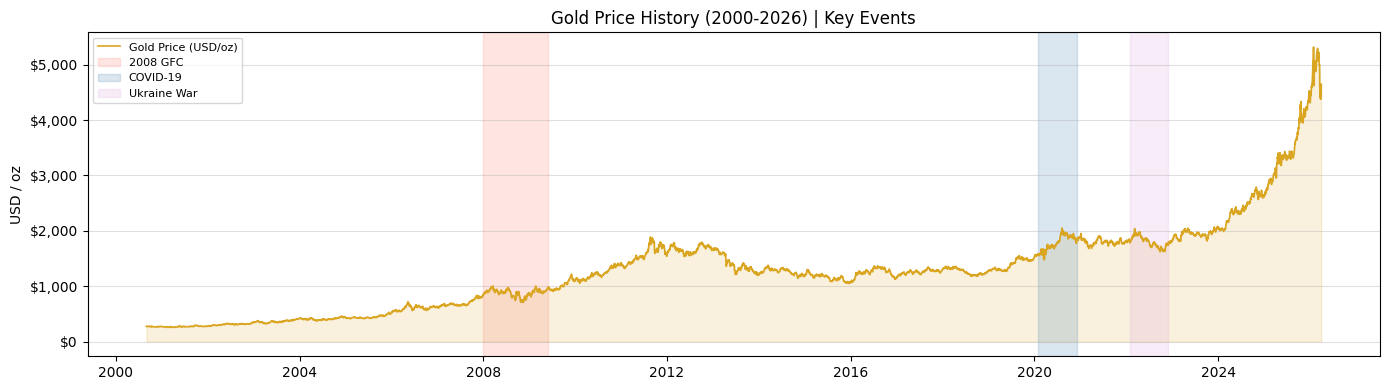

In [ ]:
# ── Cell 1 : Gold Price History + Key Economic Events ─────────────────
fig, ax = plt.subplots(figsize=(14, 4))

# Price fill + main line
ax.fill_between(df['Date'], df['Gold_Price'], alpha=0.15, color='goldenrod')
ax.plot(df['Date'], df['Gold_Price'], linewidth=1.2, color='goldenrod', label='Gold Price (USD/oz)')

# Shade major economic shocks
# These create regime breaks; flagging them helps explain model error spikes
events = [
    ('2008-01-01', '2009-06-01', 'salmon',    '2008 GFC'),
    ('2020-02-01', '2020-12-01', 'steelblue', 'COVID-19'),
    ('2022-02-01', '2022-12-01', 'plum',      'Ukraine War'),
]
for start, end, color, label in events:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.2, color=color, label=label)

ax.set_title('Gold Price History (2000-2026) | Key Events')
ax.set_ylabel('USD / oz')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.show()


## · Feature Correlation Heatmap
> **Why it matters:** Exposes multicollinearity — the key problem Lasso solves by zeroing redundant
> features. Ridge shrinks them instead. Understanding clusters tells you which features compete.


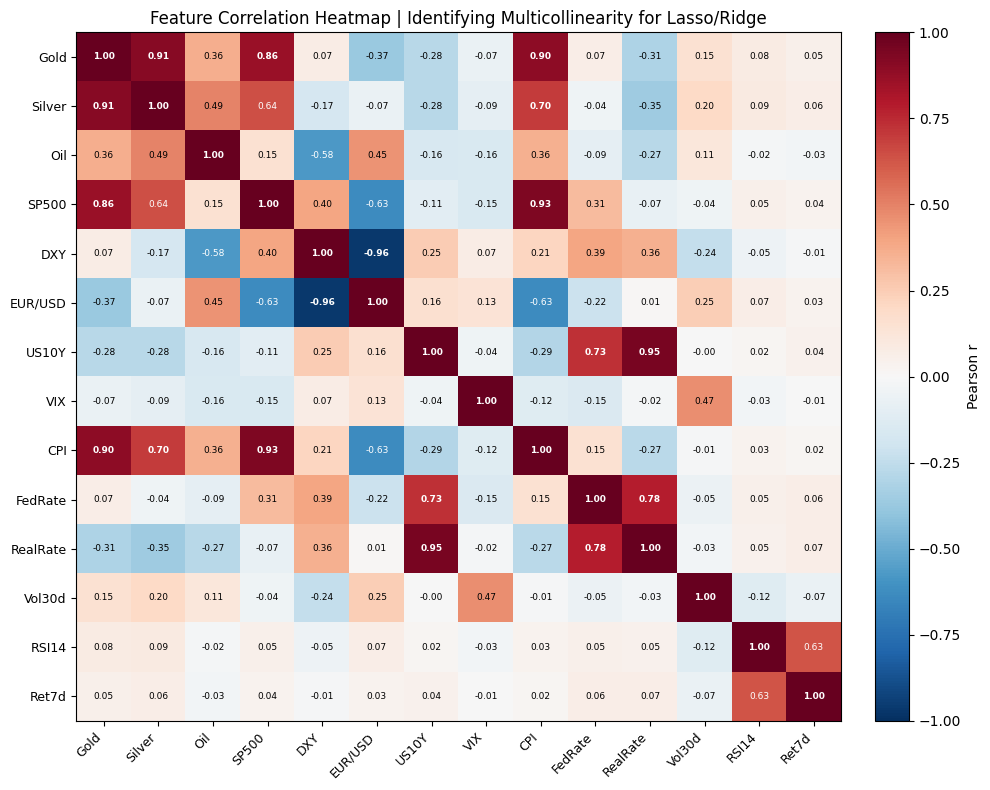

In [ ]:
# ── Cell 2: Pairwise Correlation Heatmap (Key Features) ──────────────────────

key_features = [
    'Gold_Price', 'Silver', 'Oil_WTI', 'SP500', 'DXY', 'EUR_USD',
    'US_10Y_Yield', 'VIX', 'CPI', 'Fed_Rate', 'Real_Rate_10Y',
    'Volatility_30d', 'RSI_14', 'Return_7d'
]
short_names = ['Gold', 'Silver', 'Oil', 'SP500', 'DXY', 'EUR/USD',
               'US10Y', 'VIX', 'CPI', 'FedRate', 'RealRate',
               'Vol30d', 'RSI14', 'Ret7d']

corr_matrix = df[key_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))

# Diverging colormap centred at 0: blue = negative, red = positive
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', norm=norm, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Pearson r')

ax.set_xticks(range(len(key_features)))
ax.set_yticks(range(len(key_features)))
ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(short_names, fontsize=9)

# Annotate each cell with the correlation value
for i in range(len(key_features)):
    for j in range(len(key_features)):
        v = corr_matrix.values[i, j]
        txt_color = 'white' if abs(v) > 0.55 else 'black'
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=6.5, color=txt_color,
                fontweight='bold' if abs(v) > 0.70 else 'normal')

ax.set_title('Feature Correlation Heatmap | Identifying Multicollinearity for Lasso/Ridge')
plt.tight_layout()
plt.show()


## · Feature Correlations with Gold Price
> **Why it matters:** Ranks every model input by its raw signal strength.
> Features far from zero give Lasso/Ridge the most predictive leverage — they receive
> larger (less-shrunk) coefficients.


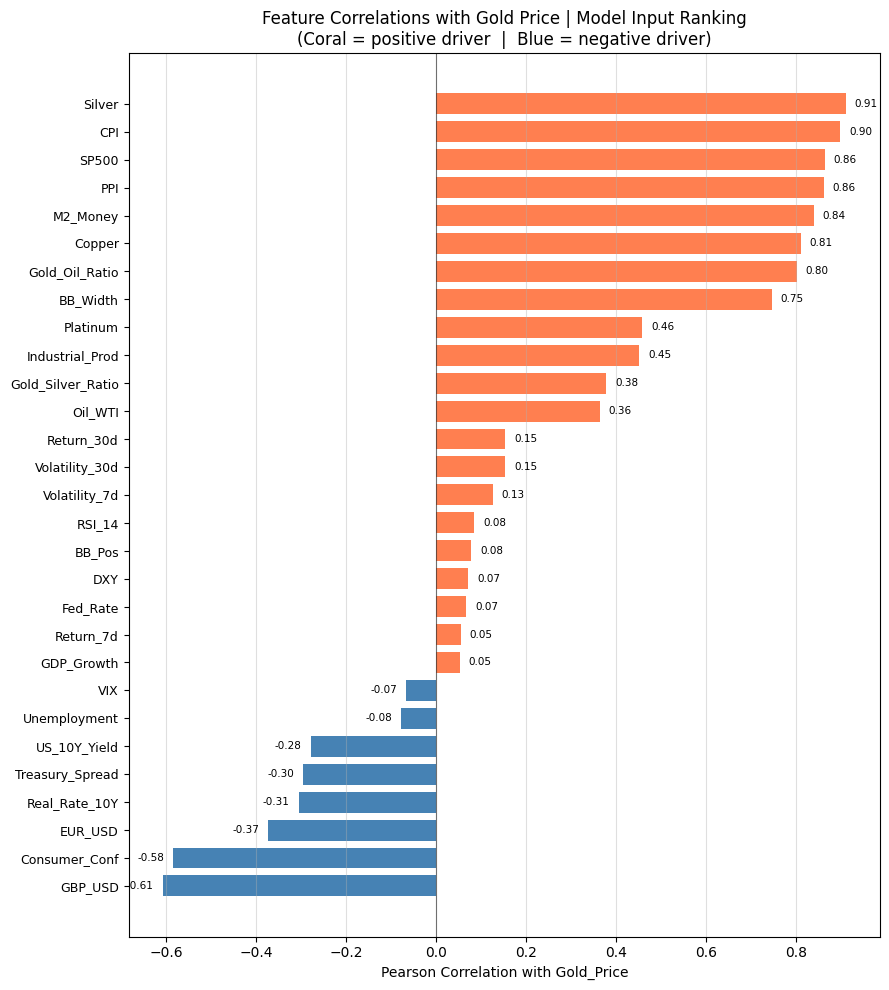

In [ ]:
# ── Cell 3: Ranked Bar Chart — Correlation of Each Feature with Gold_Price ────

non_leaky = [
    'Silver', 'Oil_WTI', 'SP500', 'DXY', 'EUR_USD', 'GBP_USD',
    'US_10Y_Yield', 'VIX', 'CPI', 'Fed_Rate', 'Real_Rate_10Y',
    'PPI', 'Platinum', 'Copper', 'Unemployment', 'GDP_Growth',
    'Consumer_Conf', 'M2_Money', 'Treasury_Spread', 'Industrial_Prod',
    'Volatility_30d', 'Volatility_7d', 'RSI_14', 'Return_7d',
    'Return_30d', 'BB_Width', 'BB_Pos', 'Gold_Silver_Ratio', 'Gold_Oil_Ratio'
]

corr_gold = (
    df[non_leaky + ['Gold_Price']]
    .corr()['Gold_Price']
    .drop('Gold_Price')
    .sort_values()
)

# Blue for negative correlations, coral for positive
colors = ['steelblue' if v < 0 else 'coral' for v in corr_gold.values]

fig, ax = plt.subplots(figsize=(9, 10))

bars = ax.barh(range(len(corr_gold)), corr_gold.values, color=colors, edgecolor='none', height=0.75)
ax.set_yticks(range(len(corr_gold)))
ax.set_yticklabels(corr_gold.index, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8, alpha=0.5)

# Value annotations on each bar
for bar, val in zip(bars, corr_gold.values):
    offset = 0.02 if val >= 0 else -0.02
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', ha=ha, fontsize=7.5)

ax.set_xlabel('Pearson Correlation with Gold_Price')
ax.set_title('Feature Correlations with Gold Price | Model Input Ranking\n'
             '(Coral = positive driver  |  Blue = negative driver)')
ax.grid(True, axis='x', alpha=0.4)
plt.tight_layout()
plt.show()


## · Gold vs Silver Scatter (colored by Year)
> **Why it matters:** Silver is highly correlated with Gold but the ratio shifts across decades.
> This is why `Gold_Silver_Ratio` is more stable than raw Silver price for Ridge/Lasso.


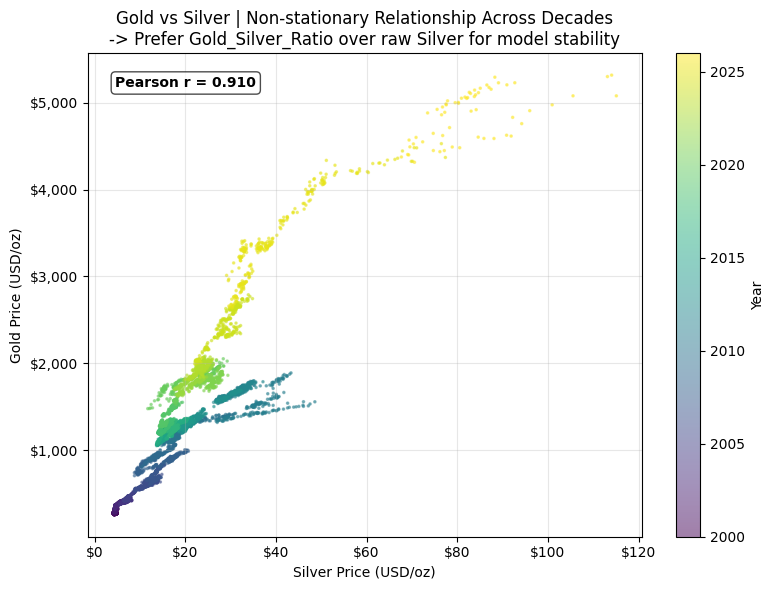

In [ ]:
# ── Cell 4 : Gold vs Silver Scatter Plot (Year-Coloured) ──────────────────────

valid = df[['Silver', 'Gold_Price', 'Year']].dropna()
r = valid['Silver'].corr(valid['Gold_Price'])

fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(valid['Silver'], valid['Gold_Price'],
                c=valid['Year'], cmap='viridis', s=2.5, alpha=0.5)
plt.colorbar(sc, ax=ax, label='Year')

# Correlation annotation
ax.text(0.05, 0.93, f'Pearson r = {r:.3f}', transform=ax.transAxes,
        fontsize=10, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax.set_xlabel('Silver Price (USD/oz)')
ax.set_ylabel('Gold Price (USD/oz)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_title('Gold vs Silver | Non-stationary Relationship Across Decades\n'
             '-> Prefer Gold_Silver_Ratio over raw Silver for model stability')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## · Missing Value Profile
> **Why it matters:** Lasso and Ridge cannot handle NaNs. This chart shows exactly where
> imputation is needed and which strategy to use — wrong imputation can introduce data leakage.


Columns with missing values: 46

MA200                1.0000
MA50                 0.9550
MA21                 0.6183
BB_Width             0.5953
BB_Lower             0.5953
BB_Upper             0.5953
BB_Pos               0.5953
RSI_14               0.4604
MSCI_World           0.4437
MA14                 0.4320
MA7                  0.2137
Gold_ETF_GLD         0.1645
EUR_USD              0.1309
GBP_USD              0.1288
TIP_ETF              0.1274
Platinum             0.1070
CNY_USD              0.0692
Lag_21d              0.0407
Momentum_14d         0.0405
Lag_14d              0.0405
Lag_7d               0.0400
Lag_3d               0.0394
Target_Next7d        0.0391
Lag_1d               0.0372
Target_NextDay       0.0371
GDP_Growth           0.0131
JPY_USD              0.0047
Return_30d           0.0045
Volatility_30d       0.0045
Return_14d           0.0020
US_10Y_Yield         0.0016
US_2Y_Yield          0.0016
Return_7d            0.0009
Volatility_7d        0.0009
VIX            

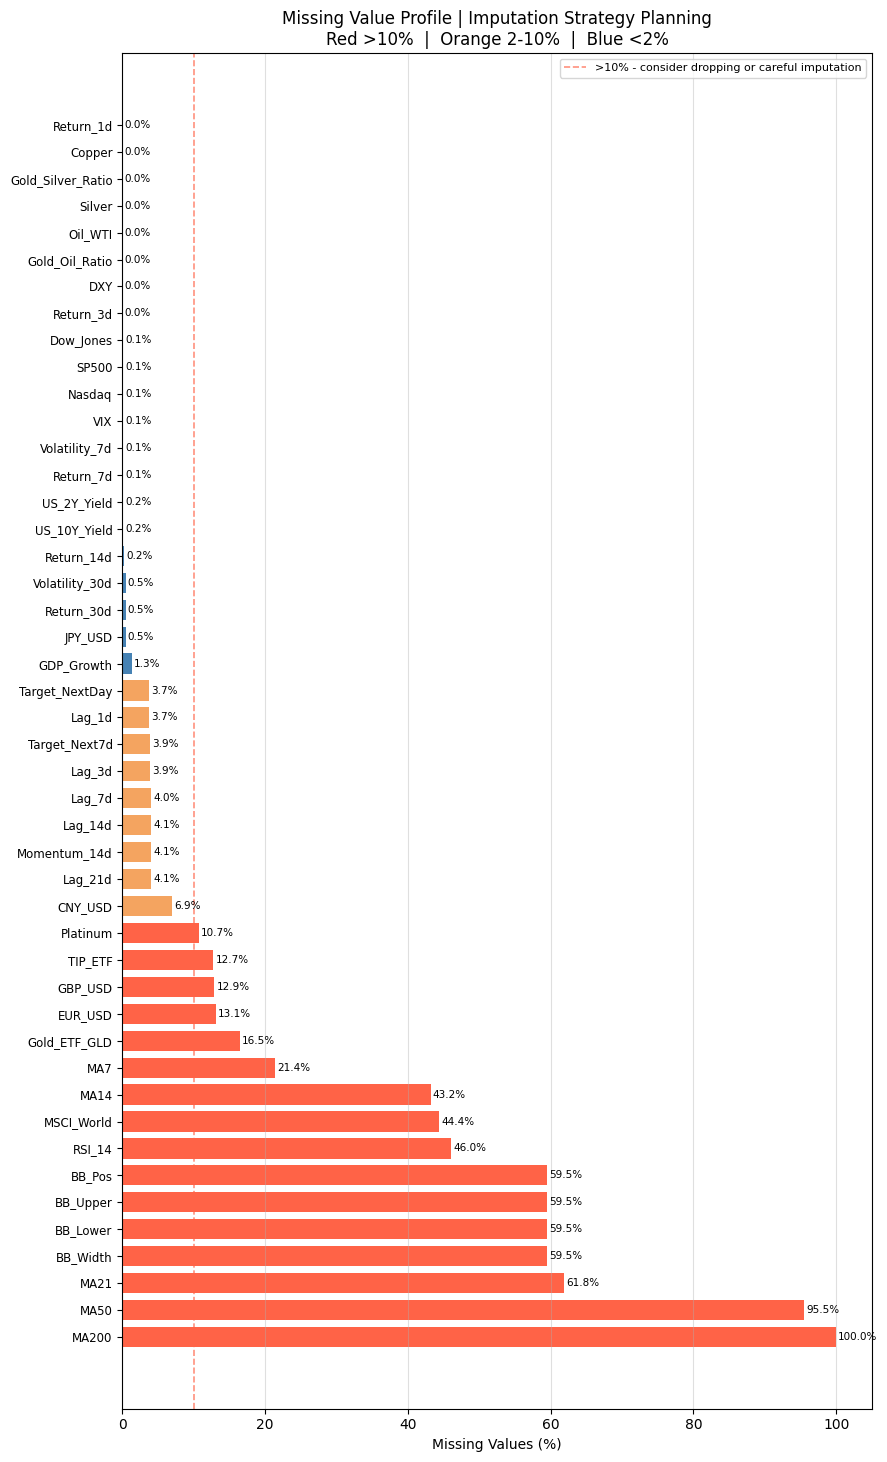

In [ ]:
# ── Cell 5 : Missing Value Profile — Imputation Planning ──────────────────────

missing_pct = df.isnull().mean().sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]  # only columns with any NaN

print(f"Columns with missing values: {len(missing_pct)}")
print()
print(missing_pct.round(4).to_string())

# Colour bars by severity
bar_colors = []
for v in missing_pct.values:
    if v > 0.10:
        bar_colors.append('tomato')       # >10%  -> high risk
    elif v > 0.02:
        bar_colors.append('sandybrown')   # 2-10% -> moderate
    else:
        bar_colors.append('steelblue')    # <2%   -> minor

fig, ax = plt.subplots(figsize=(9, max(5, len(missing_pct) * 0.32)))

bars = ax.barh(range(len(missing_pct)), missing_pct.values * 100,
               color=bar_colors, edgecolor='none', height=0.75)
ax.set_yticks(range(len(missing_pct)))
ax.set_yticklabels(missing_pct.index, fontsize=8.5)

# 10% danger line
ax.axvline(10, color='tomato', linewidth=1.2, linestyle='--', alpha=0.7,
           label='>10% - consider dropping or careful imputation')

# Value labels
for bar, val in zip(bars, missing_pct.values):
    ax.text(val * 100 + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val*100:.1f}%', va='center', fontsize=7.5)

ax.set_xlabel('Missing Values (%)')
ax.set_title('Missing Value Profile | Imputation Strategy Planning\n'
             'Red >10%  |  Orange 2-10%  |  Blue <2%')
ax.legend(fontsize=8)
ax.grid(True, axis='x', alpha=0.4)
plt.tight_layout()
plt.show()
